# Predictive Modeling

## Prepare my workspace

In [40]:
# Import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sms
from statsmodels.stats.diagnostic import linear_reset
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import warnings
import sys
# Import the related function of the utils.py file
sys.path.append("D:\Data science project\Data science\Codveda-internship\Level 2")
from Level_2.utils import general_to_specific, set_xy, split_data

warnings.filterwarnings('ignore')

In [41]:
# Load the data
reg_df = pd.read_csv(r"D:\Data science project\Data science\Codveda-internship\Level 1\Task 2\processed_real_estate.csv")

# preview the data
print("Real estates data:\n")
reg_df

Real estates data:



,name,sqm,year_built,Price(EGP),Price/Sqm,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,...,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier,Is FloorNumber outlier
0,Alamain (Latin District),92.86,2025,6594000,71010.1228,1,1,0,0,1,...,0,0,0,4.531093,15.701671,11.170578,False,False,False,False
1,Beachfront Tower - B1,398.00,2025,66104000,166090.4523,0,0,0,0,1,...,0,0,0,5.986452,18.006740,12.020288,False,False,True,False
2,PODIA,93.00,2025,12824000,137892.4731,0,1,1,0,1,...,1,0,0,4.532599,16.366829,11.834229,False,False,False,True
3,Mazarine Apartment,252.00,2025,12857000,51019.8413,1,1,0,0,0,...,0,0,0,5.529429,16.369399,10.839970,False,False,False,False
4,Alamain (Latin District),209.42,2025,8721000,41643.5870,1,1,0,0,1,...,0,0,0,5.344342,15.981244,10.636903,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,Alamain (Latin District),177.47,2025,5678000,31994.1399,1,1,0,0,1,...,0,0,0,5.178802,15.552110,10.373308,False,False,False,False
852,Jade Park,692.00,2025,25292000,36549.1329,1,0,1,1,0,...,0,0,0,6.539586,17.045999,10.506413,False,True,False,False
853,Mamsha Avenue,171.00,2025,6137000,35888.8889,1,1,0,0,1,...,0,0,0,5.141664,15.629847,10.488183,False,False,False,False
854,Alamain (Latin District),207.58,2025,5933000,28581.7516,1,1,0,0,1,...,0,0,0,5.335517,15.596041,10.260524,False,False,False,False


## Regression

### Pick the wanted features only

In [42]:
drop_cols = ["sqm","Price(EGP)","Price/Sqm",
             "year_built","FloorNumber","BuildingNumber",
             "UnitNumber","Is FloorNumber outlier","LowFloor",
             "Bedroom_0","Bathroom_0","city_Cairo",
             "governorate_Cairo","propertyCategory_Residential",
             "propertySubType_Apartment","city_Mersa Matruh",
             "governorate_Matrouh","governorate_Alexandria","governorate_Dakahlia"] # The unnecessary columns, and first dummy from every categorical column of dummies for full rank dummies, Dropping governorate Matrouh because I have two values of Matrouh with different columns
reg_df = reg_df.drop(drop_cols, axis=1) # drop these columns

# save the data for the next tasks
reg_df.to_csv("models_data.csv",index=False)
# preview the data
reg_df

,name,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,...,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier
0,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,0,0,0,4.531093,15.701671,11.170578,False,False,False
1,Beachfront Tower - B1,0,0,0,0,1,1,0,0,1,...,0,0,0,0,5.986452,18.006740,12.020288,False,False,True
2,PODIA,0,1,1,0,1,1,0,0,0,...,0,1,0,0,4.532599,16.366829,11.834229,False,False,False
3,Mazarine Apartment,1,1,0,0,0,0,1,0,1,...,0,0,0,0,5.529429,16.369399,10.839970,False,False,False
4,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,0,0,0,5.344342,15.981244,10.636903,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,0,0,0,5.178802,15.552110,10.373308,False,False,False
852,Jade Park,1,0,1,1,0,0,1,0,1,...,0,0,0,0,6.539586,17.045999,10.506413,False,True,False
853,Mamsha Avenue,1,1,0,0,1,0,1,0,1,...,0,0,0,0,5.141664,15.629847,10.488183,False,False,False
854,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,0,0,0,5.335517,15.596041,10.260524,False,False,False


### Non-outliers regression

In [43]:
outliers_list = ["Is log(price) outlier", "Is log(sqm) outlier"]
drop_cols = ["name","log(price)","Is log(price) outlier", "Is log(sqm) outlier","Is log(price/sqm) outlier", "log(price/sqm)"]
x,y = set_xy(reg_df, False, outliers_list, drop_cols) 
X_train, X_test, y_train, y_test = split_data(x,y)

x

,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,...,city_New Administrative Capital,city_New Cairo,city_North Coast,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm)
0,1,1,0,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,4.531093
2,0,1,1,0,1,1,0,0,0,1,...,0,0,0,0,1,0,1,0,0,4.532599
3,1,1,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,5.529429
4,1,1,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,5.344342
5,0,1,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,4.934474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849,1,1,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,4.867534
850,1,1,0,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,4.835567
851,1,1,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,5.178802
853,1,1,0,0,1,0,1,0,1,1,...,1,0,0,0,0,0,0,0,0,5.141664


#### Make the original model

In [44]:
def reg_summary(X_train, y_train):
    """Return the statsmodels model summary

    Args:
        X_train (DataFrame): X train matrix
        y_train (Array_like): Dependent variable
    Returns:
        Model_summary: Return the model summary(F-statistic, R-squared, etc.)
    """
### See the summary of the model using statsmodels

    reg_sms = sms.OLS(y_train, sms.add_constant(X_train)).fit()
    results = reg_sms.summary2()

    print(f"The regression model summary:\n{results}")
    
reg_summary(X_train,y_train)

The regression model summary:
                         Results: Ordinary least squares
Model:                   OLS                   Adj. R-squared:          0.814    
Dependent Variable:      log(price)            AIC:                     -12.0206 
Date:                    2025-11-02 13:41      BIC:                     116.0646 
No. Observations:        612                   Log-Likelihood:          35.010   
Df Model:                28                    F-statistic:             96.40    
Df Residuals:            583                   Prob (F-statistic):      3.27e-198
R-squared:               0.822                 Scale:                   0.054818 
---------------------------------------------------------------------------------
                                   Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
---------------------------------------------------------------------------------
const                             10.9402   0.3239 33.7773 0.0000 10.3041 11.5763
has_main_fa

Model overall statistically strong:
- F-statistic: 77.83, p-value: 0.00 --> At least one of them effect on log(price)
- R-squared: 0.822, Adj. R-squared: 0.793 --> The model explained 80% of the data which is good
- AIC, BIC: -49.0950, 82.0533 both looks fine
- Skew: 0.003(roughly normal), Kurtosis: 3.169(Roughly normal)
-JB: 0.695, p-value: 0.707 --> Fail to reject normality of residuals
- Condition Number: Very high value

> Solution: Center log(sqm), Drop one of city, Add the square of sqm because of non-linear relationship between them, and add some interactions

In [45]:
reg_df["log(sqm)_centered"] = reg_df["log(sqm)"] - x["log(sqm)"].mean() # center log(sqm)

reg_df["log(sqm) centered ** 2"] = reg_df["log(sqm)_centered"] ** 2 # centered log(sqm) ^2

reg_df.drop("log(sqm)",axis = 1, inplace=True) # drop log(sqm)

reg_df["has_full_facilities"] = reg_df["has_main_facilities"] * reg_df["has_building_facilities"] # combine them together, and drop them, because Building facilities, and main facilities are important
reg_df["has_full_facilities * modern"] = reg_df["has_full_facilities"] * reg_df["has_modern"] # full_facilities * modern
reg_df.drop(["has_main_facilities","has_building_facilities"], axis =1, inplace=True)

x,y = set_xy(reg_df, False, outliers_list, drop_cols)
X_train, X_test, y_train, y_test = split_data(x, y) # split the new data
reg_summary(X_train,y_train) # see the new model summary

The regression model summary:
                         Results: Ordinary least squares
Model:                    OLS                   Adj. R-squared:          0.809    
Dependent Variable:       log(price)            AIC:                     3.1681   
Date:                     2025-11-02 13:41      BIC:                     135.6701 
No. Observations:         612                   Log-Likelihood:          28.416   
Df Model:                 29                    F-statistic:             90.50    
Df Residuals:             582                   Prob (F-statistic):      1.61e-194
R-squared:                0.818                 Scale:                   0.056108 
----------------------------------------------------------------------------------
                                   Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
----------------------------------------------------------------------------------
const                             16.0685   0.1341 119.7963 0.0000 15.8050 16.3319


CN still high, so to solve it we can use GETS Method

#### Model selection using General to specific method

In [46]:
df = X_train.join(y_train)
final_model, removed_vars, final_vif = general_to_specific(df, "log(price)", X_train.columns)
X_train = X_train.drop(removed_vars, axis = 1)
X_test = X_test.drop(removed_vars, axis =1)

Removing Bathroom_2 due to corrected p=0.7990
Removing propertySubType_Office due to corrected p=0.8000
Removing propertySubType_Others(very rare) due to corrected p=0.9998
Removing has_other_features due to corrected p=0.3820
Removing has_full_facilities due to corrected p=0.4246
Removing MidFloor due to corrected p=0.3353
Removing propertyCategory_Commercial due to corrected p=0.3292
Removing has_modern due to corrected p=0.1397
Removing city_North Coast due to corrected p=0.0999
Removing Bathroom_1 due to corrected p=0.0891
No variable exceeds corrected p-value or VIF threshold. Selection complete.

Final VIFs:
                       Variable       VIF
                      Bedroom_3 10.843231
   has_full_facilities * modern  8.570463
                 city_Old Cairo  8.404724
                  city_Mansoura  8.049625
                      Bedroom_2  6.568279
                Bedroom_above 3  6.349929
propertySubType_Attached Houses  5.805399
              log(sqm)_centered  5.797388


- Now the model shows reliable. But residuals distribution isn't normal, so I should use robust SE methods like HC3, when doing tests, or confidence intervals

#### Fit the final model

In [47]:
sklearn_model = LinearRegression().fit(X_train, y_train)
sklearn_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


- That's better, I should do the RESET to check the linearity, and residuals, and y_pred plot

F-stat: 24.178, p-value: 0.0000


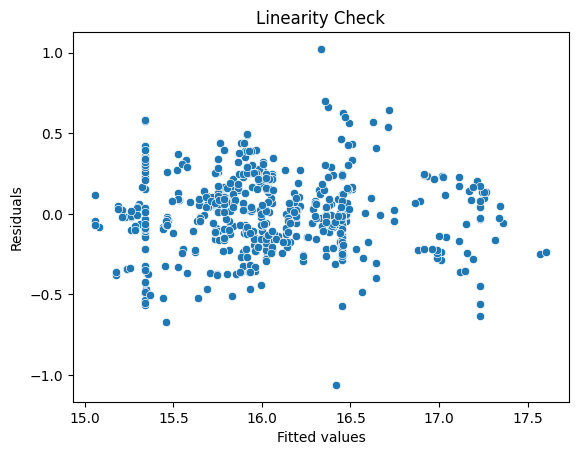

In [48]:
reset_test_results = linear_reset(final_model, power=2, use_f = True) # RESET test
print(f"F-stat: {reset_test_results.fvalue:.3f}, p-value: {reset_test_results.pvalue:.4f}")

### Store y_pred, and residuals to plot the scatterplot
y_pred = final_model.fittedvalues
residuals = final_model.resid

sns.scatterplot(x=y_pred, y=residuals);
plt.title("Linearity Check")
plt.xlabel("Fitted values")
plt.ylabel("Residuals");

Fail to reject the normality of residuals, model is well-specified. Linearity assumptions like residuals are random aren't violated

#### Model metrics

Final model metrics:
MAE     0.193541
RMSE    0.251141
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.76984676 0.76684648 0.79126873 0.82627852 0.8057221 ]


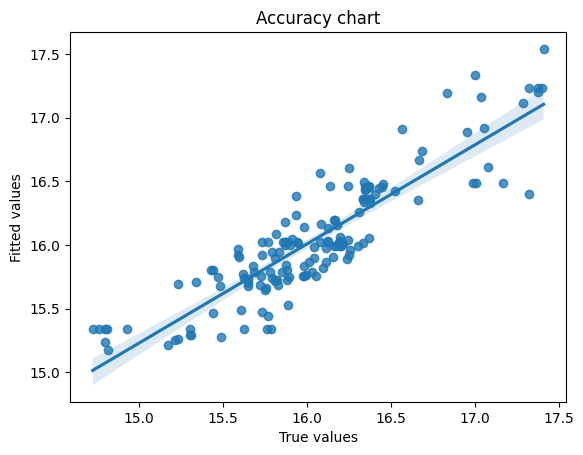

In [49]:
def model_performance(y_pred, y_test, X_train, y_train, estimator):
    """Shows the MAE, RMSE, Accuracy Chart(fitted, True), and cross validation scores(cv=5)

    Args:
        y_pred (array_like): The fitted values 
        y_test (array_like): The true values
        estimator (Model): The fitted model
    """

    mae = mean_absolute_error(y_test, y_pred) # MAE value
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # RMSE value
    # metics series
    metrics = pd.Series({
        "MAE": mae,
        "RMSE": rmse,
    }, name="Metrics")

    # plot the y_true vs. y_pred
    sns.regplot(x=y_test, y=y_pred)
    plt.title("Accuracy chart")
    plt.xlabel("True values")
    plt.ylabel("Fitted values")

    print(f"Final model metrics:\n{metrics}")
    cross_val_scores = cross_val_score(estimator, X_train, y_train, cv=5) # cross validation scores of the seen data
    print(f"Cross validation score of the seen data:\n{cross_val_scores}")
y_pred = sklearn_model.predict(X_test)
model_performance(y_pred, y_test, X_train, y_train, sklearn_model)

MAE, RMSE are close, Stable model

> Our model is stable across different samples

#### Experimental with multiple models

Decision Tree Performance:
Final model metrics:
MAE     0.118739
RMSE    0.199478
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.74786705 0.69575125 0.80434666 0.81864819 0.7594726 ]


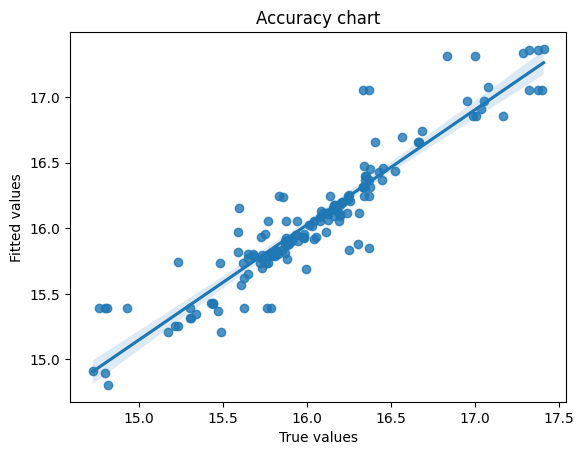

In [50]:
def decision_tree(X_train,X_test, y_test):
    """Perform a decision tree for comparing

    Args:
        X_train (array_like): the seen x data
        X_test (array_like): the unseen x data
        y_test (array_like): the actual y data
    Returns:
        Decision Tree model: The final fitted model
    """

    # Decision Tree
    dt_model = DecisionTreeRegressor(random_state=42)

    dt_model.fit(X_train, y_train)

    dt_predictions = dt_model.predict(X_test)

    print("Decision Tree Performance:")
    model_performance(dt_predictions, y_test, X_train, y_train, dt_model)
    
    return dt_model
dt_model = decision_tree(X_train,X_test, y_test)

Low MAE, and RMSE, slightly stable. This model have the lowest errors in the middle of the chart


Random Forest Performance:
Final model metrics:
MAE     0.140375
RMSE    0.205168
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.86785642 0.77006538 0.84345972 0.84951032 0.82409447]


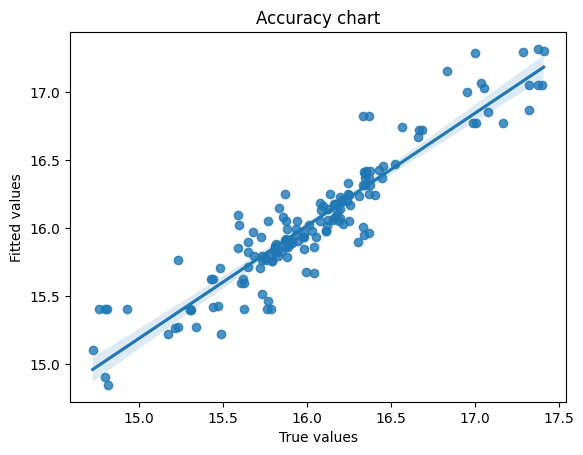

In [51]:
def random_forest(X_train, X_test, y_test):
    """Perform a Random Forest for comparing

    Args:
        X_train (array_like): the seen x data
        X_test (array_like): the unseen x data
        y_test (array_like): the actual y data
    Returns:
        Random Forest model: The final fitted model
    """
    # Random Forest
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)
    print("\nRandom Forest Performance:")
    model_performance(rf_predictions, y_test, X_train, y_train, rf_model)
    return rf_model

rf_model = random_forest(X_train, X_test, y_test)

- RandomForest model is a Stable model with lower errors in the middle of the chart, and the higher errors on the sides of the chart(right, and left). Overall the model is  great

- DecisionTree model is a Stable model with the same shape of the RandomForest. Overall the model is good

- LinearRegression model is a Stable mode, low variance. Overall the model is very good


> The best one is RandomForest model, due to it have the lowest MAE, RMSE

### Outliers regression

#### Set x,y

In [52]:
x,y = set_xy(reg_df, True, outliers_list, drop_cols) # set x, y


X_train, X_test, y_train, y_test = split_data(x,y, 0.081) # split the data into train, and test data(test_data = 10 rows)

reg_summary(X_train, y_train) # Show the model summary

The regression model summary:
                         Results: Ordinary least squares
Model:                    OLS                   Adj. R-squared:          0.984   
Dependent Variable:       log(price)            AIC:                     -83.3884
Date:                     2025-11-02 13:41      BIC:                     -32.5928
No. Observations:         83                    Log-Likelihood:          62.694  
Df Model:                 20                    F-statistic:             249.1   
Df Residuals:             62                    Prob (F-statistic):      1.48e-51
R-squared:                0.988                 Scale:                   0.017303
---------------------------------------------------------------------------------
                                   Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
---------------------------------------------------------------------------------
const                              7.4418   0.0960 77.4856 0.0000  7.2498  7.6338
has_securit

> We have high multicollinearity. The shape of the residuals isn't a normal distribution, with high skewness, with leptokurtic shape. JB p-value = 0.0 shows the non-normality of the residuals.

#### Model selection

In [53]:
df = X_train.join(y_train) # The joint data

outliers_model, removed_vars, _ = general_to_specific(df, "log(price)", X_train.columns) # Perform the model selection

Removing has_security_features due to VIF inf
Removing has_parking_safety due to VIF inf
Removing has_other_features due to VIF inf
Removing has_modern due to VIF inf
Removing has_facilities due to VIF inf
Removing Bedroom_2 due to VIF inf
Removing city_Mansoura due to VIF inf
Removing propertySubType_Office due to VIF 250.74
Removing city_North Coast due to VIF 54.21
Removing has_water_feature due to VIF 32.23
Removing has_full_facilities due to VIF 17.00
Removing propertyCategory_Commercial due to VIF 11.62
No variable exceeds corrected p-value or VIF threshold. Selection complete.

Final VIFs:
                         Variable      VIF
                log(sqm)_centered 8.462298
  city_New Administrative Capital 8.134458
                   has_green_view 7.218330
                        Bedroom_3 6.018735
propertySubType_Others(very rare) 5.964933
                   city_New Cairo 5.536826
                 Bathroom_above 2 4.912485
                       Bathroom_2 4.792786
         

> Remove the last three features because NaN vif indicating the constantly of them

In [54]:
nan_vifs = ["city_Old Cairo", "propertySubType_Attached Houses", "has_full_facilities * modern"] # the constant variables

df = df.drop(nan_vifs, axis = 1) # drop them

x,y = set_xy(df, True, outliers_list, drop_cols) # set x,y

X_train, X_test, y_train, y_test = split_data(x,y,0.081) # split them into train, and test data(test data = 10 rows)

X_train

,has_security_features,has_parking_safety,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,has_water_feature,Bedroom_1,...,city_New Administrative Capital,city_New Cairo,city_North Coast,propertyCategory_Commercial,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm)_centered,log(sqm) centered ** 2,has_full_facilities
417,0,1,0,1,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1.653187,2.733026,1
658,0,0,1,1,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0.520673,0.271100,0
174,0,0,1,1,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0.741934,0.550465,0
855,1,1,1,0,1,0,0,1,0,0,...,0,0,0,1,0,1,0,-1.506849,2.270593,0
203,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1.362132,1.855403,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,0,0,1,1,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0.741934,0.550465,0
449,1,1,1,1,0,0,1,0,0,0,...,0,1,0,1,0,0,1,-1.312693,1.723162,0
496,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1.362132,1.855403,1
719,0,0,1,1,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0.520673,0.271100,0


> Redo the model selection

In [55]:
df = X_train.join(y_train) # joint them into one data to perform the general to specific model selection

outliers_mode, removed_vars, _ = general_to_specific(df, "log(price)", X_train.columns) # model selection

X_train = X_train.drop(removed_vars, axis = 1) # remove the removed variables from x train data
X_test = X_test.drop(removed_vars, axis = 1) # remove the removed variables from x test data

Removing has_security_features due to corrected p=0.9995
Removing has_parking_safety due to corrected p=0.9621
Removing has_other_features due to corrected p=0.9980
Removing HighFloor due to corrected p=1.0000


Removing MidFloor due to corrected p=1.0000
Removing has_modern due to corrected p=1.0000
Removing has_water_feature due to corrected p=0.9948
Removing has_facilities due to corrected p=0.9799
Removing has_green_view due to corrected p=0.9982
Removing Bedroom_1 due to corrected p=0.9980
Removing Bedroom_2 due to corrected p=0.9980
Removing Bedroom_3 due to corrected p=0.9961
Removing Bathroom_1 due to corrected p=0.9995
Removing Bathroom_2 due to corrected p=0.6616
Removing city_Mansoura due to corrected p=0.9682
Removing city_New Cairo due to corrected p=0.9329
Removing city_New Administrative Capital due to corrected p=0.9480
Removing propertySubType_Office due to corrected p=0.9591
Removing Bedroom_above 3 due to corrected p=0.6620
Removing has_full_facilities due to corrected p=0.4807
No variable exceeds corrected p-value or VIF threshold. Selection complete.

Final VIFs:
                         Variable      VIF
      propertyCategory_Commercial 7.406986
                log(sqm)_

> Now that's better. There is no high skewness, but we have a strong leptokurtic shape, and JB shows that the shape of residuals not a normal distribution, but f-statistic shows that at least one of feature effect on the log of price

Final model metrics:
MAE     0.117262
RMSE    0.132419
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.87416527 0.96721524 0.92312003 0.94739723 0.90560961]


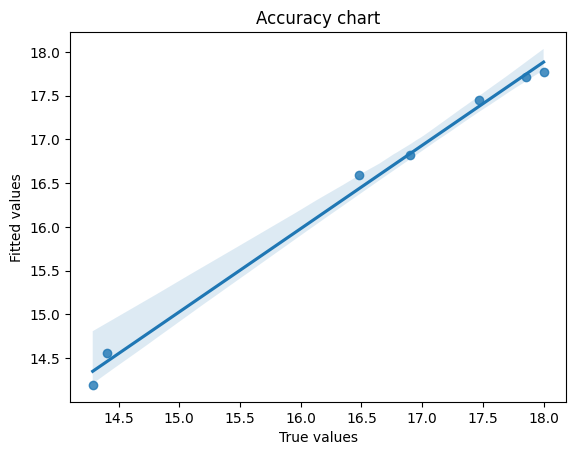

In [56]:
outliers_model_sklearn = LinearRegression().fit(X_train, y_train) # outliers sklearn model

y_pred = outliers_model_sklearn.predict(X_test) # store the fitted y(10 rows)

model_performance(y_pred, y_test, X_train, y_train, outliers_model_sklearn) # Show the model performance using test data(10 rows)

- The model is stable for outliers real estates(Extreme, prices, and sqm), good MAE, and RMSE

#### Random forest, and decision tree models

##### Decision tree model

Decision Tree Performance:
Final model metrics:
MAE     0.135560
RMSE    0.181015
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.51207304 0.8338535  0.8429688  0.95905532 0.39379484]


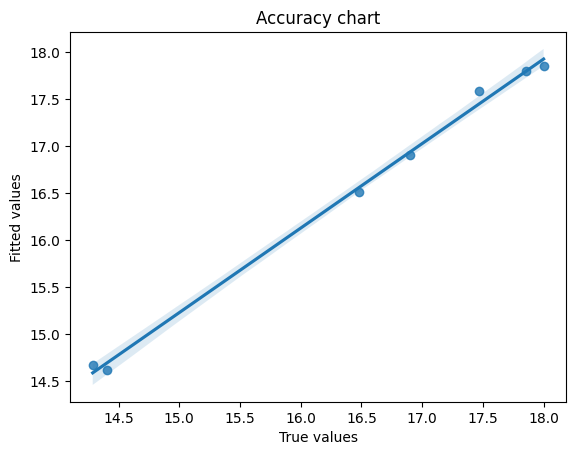

In [57]:
outliers_dt_model = decision_tree(X_train, X_test, y_test) # decision tree model of outliers data

- The model performance is moderate, good MAE, and RMSE

##### Random forest model


Random Forest Performance:
Final model metrics:
MAE     0.160752
RMSE    0.217701
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.80089129 0.87221485 0.88677631 0.95308541 0.43939211]


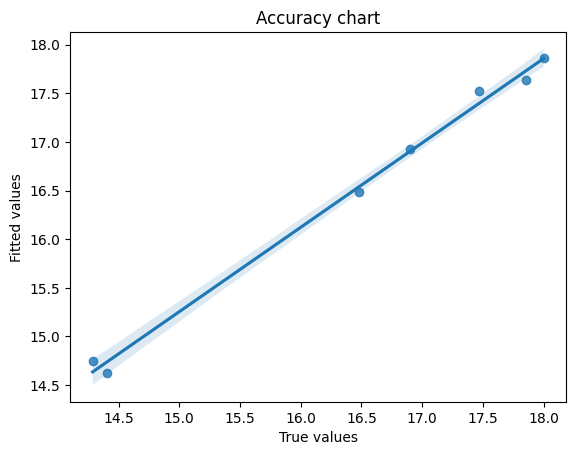

In [58]:
rf_outliers_model = random_forest(X_train, X_test, y_test) # Random forest model of outliers data

- The most stable model performance compared to the other models

#### summary:

The final best model is the Linear regression model due to stability, and low MAE, RMSE in outliers models

## Summary:

- The best model in outliers is Linear regression, and non_outliers is Random forest model
- The number of features of outliers model is less than the outliers model due to high Vifs, and p-values
- The non-outliers models shows a stable performance, good MAE, RMSE, but outliers models shows a slightly stable models, good MAE, RMSE due to the shocks in the data
- The non-outliers model explained $\approx$ 80% of the data, but the outliers model explained $\approx$ 96% of the data due to the small number of observation compared to the non-outliers number of observations 
- Performed model specification, and model selection using GETS method
- Performed model evaluation to compare different models to get the best AIC, $R^2$, and stability